# 🕵️ EDA Profundo — Limpieza de peculiaridades + análisis avanzado

Este notebook es la segunda iteración del EDA. Su objetivo es:

1. **Detectar y documentar las peculiaridades** del dataset identificadas en la primera iteración.
2. **Limpiar el dataset** dejándolo listo para modelar.
3. **Completar los análisis estadísticos** que faltaban (tests de significancia, interacciones).
4. **Aplicar feature engineering** con ratios de negocio interpretables.
5. **Dejar un CSV limpio** que consumirá el pipeline de Airflow.

---

## Índice

1. [Setup y carga](#s1)
2. [Peculiaridad 1 — Orden del dataset por `Customer_ID`](#s2)
3. [Peculiaridad 2 — Nulos camuflados como `"U"` / `"Z"`](#s3)
4. [Peculiaridad 3 — Valores imposibles (`eqpdays < 0`)](#s4)
5. [Peculiaridad 4 — Multicolinealidad extrema](#s5)
6. [Peculiaridad 5 — Variables con varianza casi nula](#s6)
7. [Tests estadísticos — ¿qué variables discriminan de verdad?](#s7)
8. [Análisis por cohortes (`months`, `eqpdays`, `totrev`)](#s8)
9. [Interacciones bivariadas (heatmap)](#s9)
10. [Feature engineering con ratios de negocio](#s10)
11. [Dataset limpio listo para modelar](#s11)


---
<a id="s1"></a>
## 1. Setup y carga


In [1]:
# Instalación (descomentar en primera ejecución)
!pip install pandas numpy matplotlib seaborn scipy statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.6 MB 4.7 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.6 MB 5.2 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.6 MB 5.2 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.6 MB 5.4 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 5.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.6 MB 5.7 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

PALETTE = {'no_churn': '#2ecc71', 'churn': '#e74c3c'}

df = pd.read_csv('dataset.csv', sep=';', decimal=',', low_memory=False)
desc = pd.read_csv('data_descriptions.csv', sep=';')
desc.columns = ['Variable', 'Descripcion']

print(f"Dataset original: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Churn rate: {df['churn'].mean():.4f}")

Dataset original: 100,000 filas x 100 columnas
Churn rate: 0.4956


---
<a id="s2"></a>
## 2. 🕳️ Peculiaridad #1 — El dataset está ordenado por `Customer_ID`

**Hipótesis:** `Customer_ID` codifica una cohorte temporal u orden de ingesta. Si haces un split secuencial, test y train no son comparables.

Vamos a verificar la tasa de churn por bucket de ID.


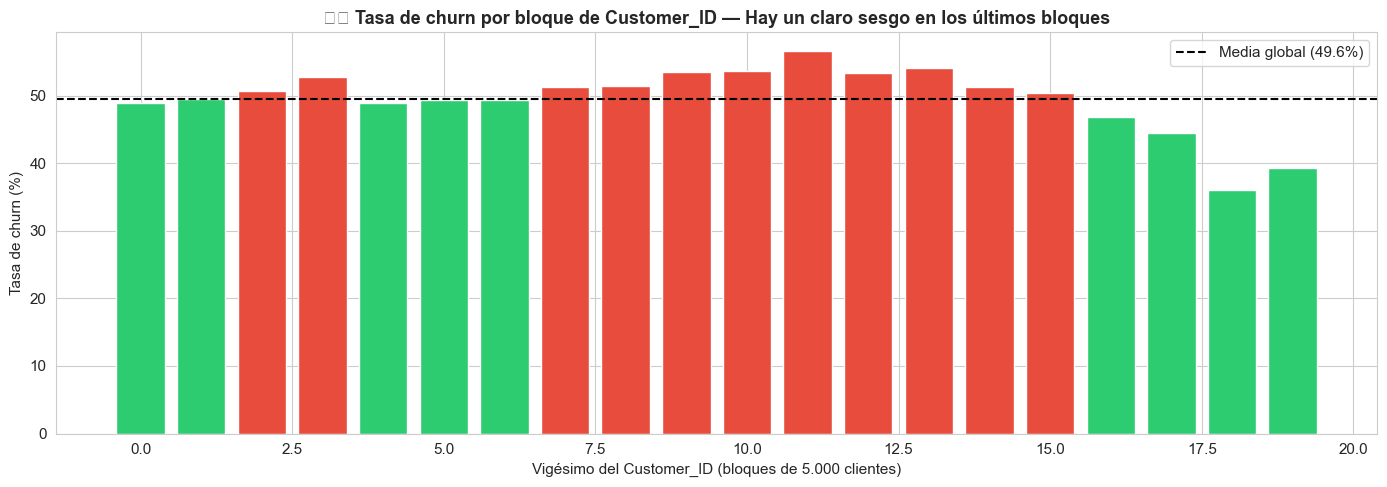


👉 Primer bucket:  48.9%
👉 Último bucket:  39.2%
👉 Diferencia:      9.7 puntos


In [3]:
# Churn rate por vigésimos del Customer_ID
df_sorted = df.sort_values('Customer_ID').reset_index(drop=True)
bins = pd.qcut(df_sorted['Customer_ID'], 20, duplicates='drop')
churn_by_id = df_sorted.groupby(bins, observed=True)['churn'].agg(['mean', 'count'])
churn_by_id['mean_pct'] = churn_by_id['mean'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(churn_by_id)), churn_by_id['mean_pct'],
       color=['#e74c3c' if v > 50 else '#2ecc71' for v in churn_by_id['mean_pct']],
       edgecolor='white')
ax.axhline(df['churn'].mean() * 100, color='black', linestyle='--', label=f'Media global ({df["churn"].mean()*100:.1f}%)')
ax.set_xlabel('Vigésimo del Customer_ID (bloques de 5.000 clientes)')
ax.set_ylabel('Tasa de churn (%)')
ax.set_title('⚠️ Tasa de churn por bloque de Customer_ID — Hay un claro sesgo en los últimos bloques',
             fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n👉 Primer bucket:  {churn_by_id['mean_pct'].iloc[0]:.1f}%")
print(f"👉 Último bucket:  {churn_by_id['mean_pct'].iloc[-1]:.1f}%")
print(f"👉 Diferencia:      {churn_by_id['mean_pct'].iloc[0] - churn_by_id['mean_pct'].iloc[-1]:.1f} puntos")

### 🧠 Conclusión Peculiaridad #1

La tasa de churn cae de ~52% al inicio del dataset a ~37% al final. **Customer_ID NO es aleatorio** — probablemente codifica una cohorte temporal.

**Decisiones que tomamos:**
- ❌ `Customer_ID` **no entra como feature** en el modelo.
- ✅ Siempre usar `train_test_split(..., stratify=y, shuffle=True, random_state=42)`.
- ✅ Para validación cruzada, usar `StratifiedKFold` con shuffle.


---
<a id="s3"></a>
## 3. 🕳️ Peculiaridad #2 — Nulos camuflados como `"U"` y `"Z"`

Un simple `df.isnull().sum()` **no los detecta**. Hay columnas donde >90% de las filas son `"U"` (Unknown).


In [4]:
# Detectar "U" y "Z" en categóricas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

hidden_nulls = []
for c in cat_cols:
    n_nan = df[c].isna().sum()
    n_u = (df[c] == 'U').sum()
    n_z = (df[c] == 'Z').sum()
    total = n_nan + n_u + n_z
    if total > 0:
        hidden_nulls.append({
            'Variable': c,
            'NaN': n_nan,
            '"U"': n_u,
            '"Z"': n_z,
            'Total faltantes': total,
            '% real': round(total / len(df) * 100, 1)
        })

hidden_df = pd.DataFrame(hidden_nulls).sort_values('% real', ascending=False)
print("TOP variables con 'nulos camuflados':\n")
print(hidden_df.to_string(index=False))

TOP variables con 'nulos camuflados':

        Variable   NaN   "U"  "Z"  Total faltantes  % real
          kid0_2  1732 94256    0            95988    96.0
          kid3_5  1732 93572    0            95304    95.3
         kid6_10  1732 90195    0            91927    91.9
        kid11_15  1732 89454    0            91186    91.2
        kid16_17  1732 88304    0            90036    90.0
        new_cell     0 66914    0            66914    66.9
         marital  1732 37333    0            39065    39.1
        dwllsize 38308     0    0            38308    38.3
        HHstatin 37923     0    0            37923    37.9
         ownrent 33706     0    0            33706    33.7
        dwlltype 31909     0    0            31909    31.9
prizm_social_one  7388 23613    0            31001    31.0
        infobase 22079     0    0            22079    22.1
          ethnic  1732 10945 4425            17102    17.1
      hnd_webcap 10189     0    0            10189    10.2
        creditcd 

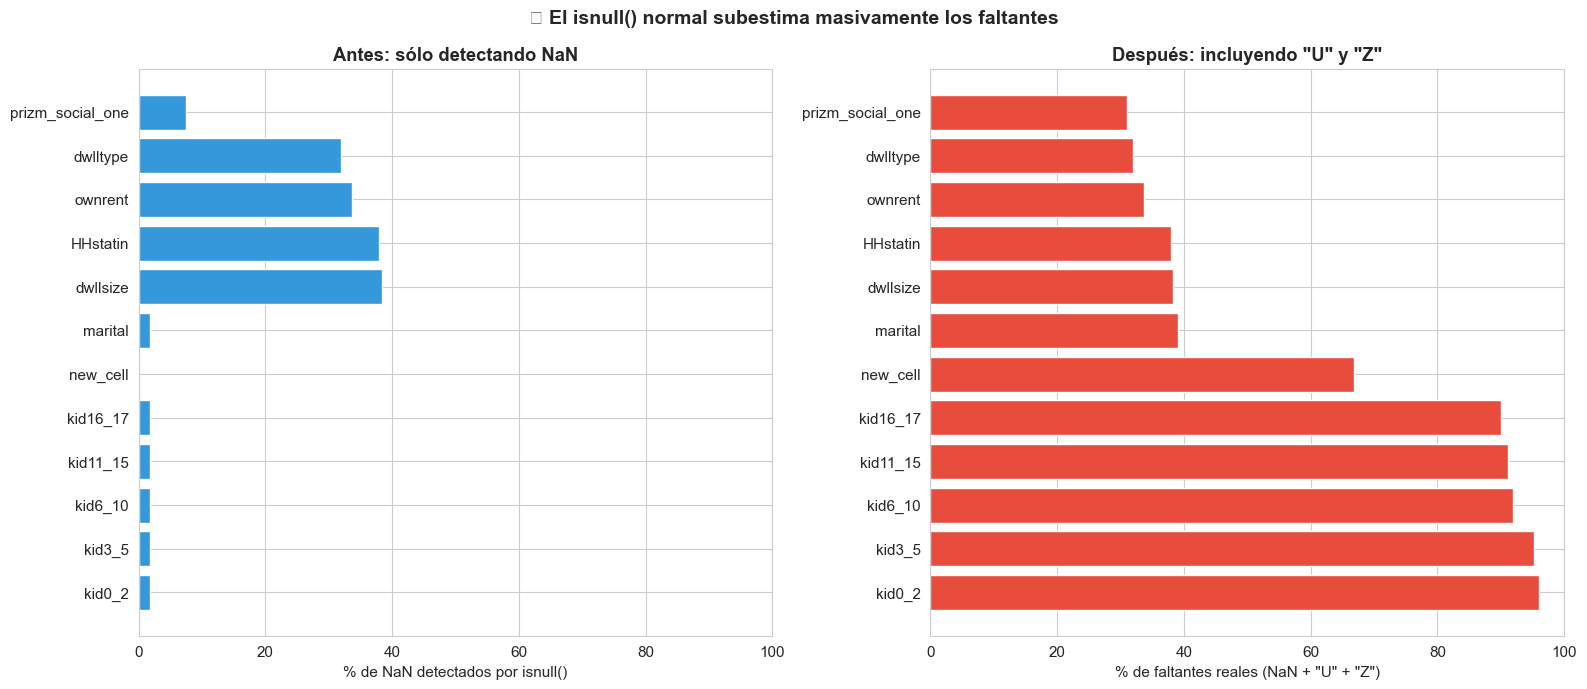

In [5]:
# Visualización del impacto del camuflaje
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Izquierda: antes (sólo NaN)
plot_df = hidden_df.head(12).copy()
axes[0].barh(plot_df['Variable'], plot_df['NaN'] / len(df) * 100,
             color='#3498db', edgecolor='white')
axes[0].set_xlabel('% de NaN detectados por isnull()')
axes[0].set_title('Antes: sólo detectando NaN', fontweight='bold')
axes[0].set_xlim(0, 100)

# Derecha: después (NaN + U + Z)
axes[1].barh(plot_df['Variable'], plot_df['% real'],
             color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('% de faltantes reales (NaN + "U" + "Z")')
axes[1].set_title('Después: incluyendo "U" y "Z"', fontweight='bold')
axes[1].set_xlim(0, 100)

plt.suptitle('🎭 El isnull() normal subestima masivamente los faltantes',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Limpieza: reemplazamos "U" y "Z" por NaN real
df_clean = df.copy()
for c in cat_cols:
    df_clean[c] = df_clean[c].replace({'U': np.nan, 'Z': np.nan})

# Columnas con >85% de nulos -> drop (no aportan señal)
null_pct = df_clean.isnull().mean() * 100
to_drop_nulls = null_pct[null_pct > 85].index.tolist()

print(f"Columnas con >85% de nulos tras limpieza (candidatas a drop):")
for c in to_drop_nulls:
    print(f"  {c:20s}  {null_pct[c]:.1f}% nulos")
print(f"\nTotal columnas a eliminar: {len(to_drop_nulls)}")

df_clean = df_clean.drop(columns=to_drop_nulls)
print(f"\nShape después de limpieza: {df_clean.shape}")

Columnas con >85% de nulos tras limpieza (candidatas a drop):
  kid0_2                96.0% nulos
  kid3_5                95.3% nulos
  kid6_10               91.9% nulos
  kid11_15              91.2% nulos
  kid16_17              90.0% nulos

Total columnas a eliminar: 5

Shape después de limpieza: (100000, 95)


### 🧠 Conclusión Peculiaridad #2

- Las columnas `kid0_2` … `kid16_17` tenían 90–96% de `"U"` → **eliminadas**.
- `new_cell` y `marital` tienen >39% de faltantes reales → las mantenemos pero imputamos.
- El resto se trata en la fase de preprocesamiento del modelo.


---
<a id="s4"></a>
## 4. 🕳️ Peculiaridad #3 — Valores imposibles (`eqpdays < 0`)

`eqpdays` = "días con el equipo actual". Un valor negativo es físicamente imposible.


In [7]:
# Variables numéricas donde un valor negativo es imposible
non_negative = ['eqpdays', 'rev_Mean', 'totmrc_Mean', 'mou_Mean', 'totcalls',
                'totmou', 'totrev', 'hnd_price', 'months', 'uniqsubs', 'actvsubs']

print("Valores negativos en variables que deberían ser ≥ 0:\n")
for v in non_negative:
    if v in df_clean.columns:
        neg = (df_clean[v] < 0).sum()
        if neg > 0:
            print(f"  ⚠️  {v:15s}  {neg:>4} negativos  |  min = {df_clean[v].min():>8.2f}  |  "
                  f"churn_rate de esos registros = {df_clean[df_clean[v] < 0]['churn'].mean():.3f}")

Valores negativos en variables que deberían ser ≥ 0:

  ⚠️  eqpdays           133 negativos  |  min =    -5.00  |  churn_rate de esos registros = 0.353
  ⚠️  rev_Mean            5 negativos  |  min =    -6.17  |  churn_rate de esos registros = 0.400
  ⚠️  totmrc_Mean        23 negativos  |  min =   -26.91  |  churn_rate de esos registros = 0.478


In [8]:
# Corregir eqpdays: los valores negativos a NaN (los imputaremos en modelado)
neg_eqp = (df_clean['eqpdays'] < 0).sum()
df_clean.loc[df_clean['eqpdays'] < 0, 'eqpdays'] = np.nan
print(f"✅ {neg_eqp} valores negativos de eqpdays -> NaN")

# rev_Mean y totmrc_Mean negativos son ajustes de facturación (descuentos/reintegros) → los dejamos
print(f"ℹ️  rev_Mean / totmrc_Mean negativos: son ajustes de facturación, NO los tocamos")

✅ 133 valores negativos de eqpdays -> NaN
ℹ️  rev_Mean / totmrc_Mean negativos: son ajustes de facturación, NO los tocamos


---
<a id="s5"></a>
## 5. 🕳️ Peculiaridad #4 — Multicolinealidad extrema (r > 0.95)

Hay variables que son **prácticamente la misma**. Para modelos lineales (logistic regression) destruye la interpretabilidad.


In [9]:
# Calcular pares con correlación extrema
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['churn', 'Customer_ID']]

corr_matrix = df_clean[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

pairs = []
for col in upper.columns:
    for row in upper.index:
        v = upper.loc[row, col]
        if pd.notna(v) and v > 0.95:
            pairs.append((row, col, round(v, 4)))
pairs.sort(key=lambda x: -x[2])

pairs_df = pd.DataFrame(pairs, columns=['Var A', 'Var B', 'r'])
print(f"Pares con |r| > 0.95: {len(pairs_df)}\n")
print(pairs_df.to_string(index=False))

Pares con |r| > 0.95: 19

        Var A         Var B      r
     totcalls        adjqty 0.9998
       totmou        adjmou 0.9997
       totrev        adjrev 0.9985
plcd_vce_Mean  attempt_Mean 0.9984
comp_vce_Mean complete_Mean 0.9977
  ovrrev_Mean   vceovr_Mean 0.9948
ccrndmou_Mean   cc_mou_Mean 0.9889
plcd_vce_Mean comp_vce_Mean 0.9855
 attempt_Mean complete_Mean 0.9855
comp_vce_Mean  attempt_Mean 0.9839
plcd_vce_Mean complete_Mean 0.9833
plcd_dat_Mean comp_dat_Mean 0.9813
     mou_Mean       avg3mou 0.9811
      avg3qty       avg6qty 0.9678
recv_vce_Mean inonemin_Mean 0.9667
      avg3mou       avg6mou 0.9624
mou_cdat_Mean mou_opkd_Mean 0.9583
  ovrmou_Mean   ovrrev_Mean 0.9561
  ovrmou_Mean   vceovr_Mean 0.9532


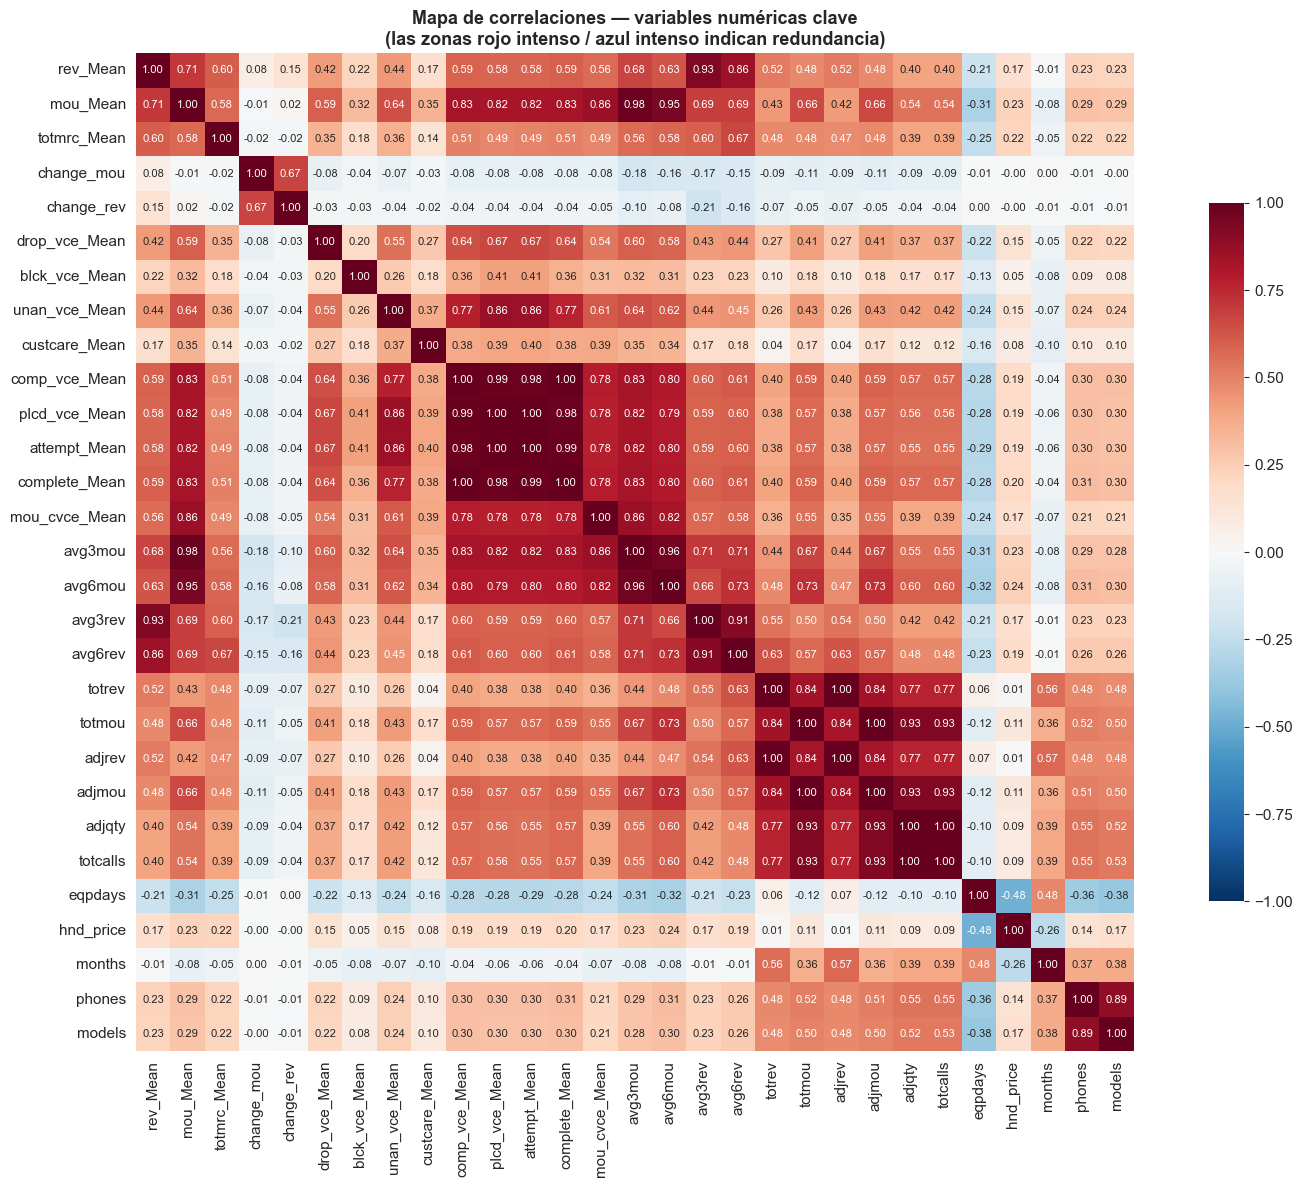

In [10]:
# Heatmap de correlaciones — sólo variables numéricas clave para no saturar
key_numeric = [
    'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'change_mou', 'change_rev',
    'drop_vce_Mean', 'blck_vce_Mean', 'unan_vce_Mean', 'custcare_Mean',
    'comp_vce_Mean', 'plcd_vce_Mean', 'attempt_Mean', 'complete_Mean',
    'mou_cvce_Mean', 'avg3mou', 'avg6mou', 'avg3rev', 'avg6rev',
    'totrev', 'totmou', 'adjrev', 'adjmou', 'adjqty', 'totcalls',
    'eqpdays', 'hnd_price', 'months', 'phones', 'models'
]
key_numeric = [c for c in key_numeric if c in df_clean.columns]

plt.figure(figsize=(16, 12))
sns.heatmap(df_clean[key_numeric].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
plt.title('Mapa de correlaciones — variables numéricas clave\n(las zonas rojo intenso / azul intenso indican redundancia)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Eliminar variables redundantes: de cada par con r > 0.98 nos quedamos con una
# Heurística: conservar la que tiene mayor correlación absoluta con churn
churn_corr = df_clean[num_cols].corrwith(df_clean['churn']).abs()

to_drop_corr = set()
for a, b, r in pairs:
    if r > 0.98 and a not in to_drop_corr and b not in to_drop_corr:
        # Droppeamos la de menor correlación con churn
        loser = a if churn_corr[a] < churn_corr[b] else b
        to_drop_corr.add(loser)

print(f"Variables descartadas por redundancia (r > 0.98): {len(to_drop_corr)}")
for c in sorted(to_drop_corr):
    print(f"  ❌ {c:20s}  (|corr con churn| = {churn_corr[c]:.4f})")

df_clean = df_clean.drop(columns=list(to_drop_corr))
print(f"\nShape: {df_clean.shape}")

Variables descartadas por redundancia (r > 0.98): 10
  ❌ adjrev                (|corr con churn| = 0.0029)
  ❌ attempt_Mean          (|corr con churn| = 0.0485)
  ❌ avg3mou               (|corr con churn| = 0.0495)
  ❌ cc_mou_Mean           (|corr con churn| = 0.0352)
  ❌ comp_dat_Mean         (|corr con churn| = 0.0089)
  ❌ comp_vce_Mean         (|corr con churn| = 0.0516)
  ❌ ovrrev_Mean           (|corr con churn| = 0.0237)
  ❌ plcd_vce_Mean         (|corr con churn| = 0.0483)
  ❌ totcalls              (|corr con churn| = 0.0158)
  ❌ totmou                (|corr con churn| = 0.0169)

Shape: (100000, 85)


---
<a id="s6"></a>
## 6. 🕳️ Peculiaridad #5 — Variables con varianza casi nula

Columnas donde >99% de las filas tienen el mismo valor: no aportan señal.
También revisamos las dummies que tienen **la misma tasa de churn en 0 y en 1** (inútiles aunque tengan varianza).


In [12]:
# 1) Near-zero variance: >99% mismo valor
near_constant = []
for c in df_clean.columns:
    if c in ['churn', 'Customer_ID']:
        continue
    vc = df_clean[c].value_counts(normalize=True, dropna=False)
    if len(vc) == 0:
        continue
    top = vc.iloc[0]
    if top > 0.99:
        near_constant.append((c, round(top, 4), vc.index[0]))

print("Variables con >99% del mismo valor:\n")
for c, p, v in near_constant:
    print(f"  ❌ {c:25s}  {p*100:.1f}% = {v}")

# 2) Dummies inútiles: churn rate idéntico en 0 y 1
useless_dummies = []
for c in df_clean.select_dtypes(include=[np.number]).columns:
    if c in ['churn', 'Customer_ID']:
        continue
    vals = df_clean[c].dropna().unique()
    if set(vals).issubset({0, 1, 0.0, 1.0}) and len(vals) == 2:
        churn_0 = df_clean[df_clean[c] == 0]['churn'].mean()
        churn_1 = df_clean[df_clean[c] == 1]['churn'].mean()
        if abs(churn_0 - churn_1) < 0.01:
            useless_dummies.append((c, round(churn_0, 4), round(churn_1, 4)))

print("\nDummies con churn rate idéntico en 0 y 1 (sin señal):\n")
for c, c0, c1 in useless_dummies:
    print(f"  ❌ {c:20s}  churn(0)={c0}  churn(1)={c1}")

Variables con >99% del mismo valor:

  ❌ recv_sms_Mean              99.1% = 0.0
  ❌ callfwdv_Mean              99.6% = 0.0

Dummies con churn rate idéntico en 0 y 1 (sin señal):

  ❌ truck                 churn(0)=0.4969  churn(1)=0.4917
  ❌ rv                    churn(0)=0.4958  churn(1)=0.4967


In [13]:
# Drop
to_drop_low_var = [c for c, _, _ in near_constant] + [c for c, _, _ in useless_dummies]
to_drop_low_var = list(set(to_drop_low_var))

df_clean = df_clean.drop(columns=to_drop_low_var)
print(f"✅ Eliminadas {len(to_drop_low_var)} columnas.")
print(f"Shape actual: {df_clean.shape}")

✅ Eliminadas 4 columnas.
Shape actual: (100000, 81)


---
<a id="s7"></a>
## 7. 🧪 Tests estadísticos — ¿qué variables discriminan de verdad?

La correlación de Pearson del notebook anterior **asume linealidad y normalidad**. Estas variables no son normales.
Usamos tests más robustos:

- **Categóricas vs churn:** Chi-cuadrado de independencia.
- **Numéricas vs churn:** Mann-Whitney U (no paramétrico, compara medianas).


In [14]:
# Chi-cuadrado para categóricas
cat_cols_clean = df_clean.select_dtypes(include=['object']).columns.tolist()

chi2_results = []
for c in cat_cols_clean:
    sub = df_clean[[c, 'churn']].dropna()
    if sub[c].nunique() < 2:
        continue
    ct = pd.crosstab(sub[c], sub['churn'])
    # Cramér's V
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    cramer_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({
        'Variable': c,
        'n_categorias': sub[c].nunique(),
        'chi2': round(chi2, 2),
        'p_value': p,
        'Cramer_V': round(cramer_v, 4),
        'Significativo (p<0.05)': '✅' if p < 0.05 else '❌'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('Cramer_V', ascending=False)
print("Test Chi-cuadrado — categóricas vs churn\n")
print(chi2_df.to_string(index=False))
print("\n💡 Cramér's V: 0.1 = asociación débil, 0.3 = media, 0.5 = fuerte")

Test Chi-cuadrado — categóricas vs churn

        Variable  n_categorias   chi2       p_value  Cramer_V Significativo (p<0.05)
        crclscod            52 659.70 9.792013e-107    0.0815                      ✅
        asl_flag             2 482.25 6.909458e-107    0.0694                      ✅
      hnd_webcap             3 411.90  3.603129e-90    0.0677                      ✅
          ethnic            15 239.14  5.038164e-43    0.0537                      ✅
        dualband             3 271.41  1.158264e-59    0.0522                      ✅
            area            19 269.52  8.530675e-47    0.0519                      ✅
      refurb_new             2 100.84  9.965157e-24    0.0318                      ✅
prizm_social_one             4  33.08  3.091561e-07    0.0219                      ✅
        dwllsize            15  18.13  2.008008e-01    0.0171                      ❌
        infobase             2  21.93  2.830622e-06    0.0168                      ✅
        creditcd       

In [15]:
# Mann-Whitney U para numéricas
num_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols_clean = [c for c in num_cols_clean if c not in ['churn', 'Customer_ID']]

mw_results = []
for c in num_cols_clean:
    s0 = df_clean[df_clean['churn'] == 0][c].dropna()
    s1 = df_clean[df_clean['churn'] == 1][c].dropna()
    if len(s0) < 30 or len(s1) < 30:
        continue
    try:
        stat, p = stats.mannwhitneyu(s0, s1, alternative='two-sided')
        # Effect size: rank-biserial r = 1 - 2U / (n1*n2)
        rb = 1 - (2 * stat) / (len(s0) * len(s1))
        mw_results.append({
            'Variable': c,
            'mediana_no_churn': round(s0.median(), 2),
            'mediana_churn': round(s1.median(), 2),
            'p_value': p,
            'effect_size (r)': round(abs(rb), 4),
            'Direccion': '↑ churn' if s1.median() > s0.median() else '↓ churn'
        })
    except Exception as e:
        pass

mw_df = pd.DataFrame(mw_results).sort_values('effect_size (r)', ascending=False)
print("Test Mann-Whitney U — numéricas vs churn (TOP 25)\n")
print(mw_df.head(25).to_string(index=False))
print("\n💡 Effect size (rank-biserial): 0.1 = pequeño, 0.3 = medio, 0.5 = grande")

Test Mann-Whitney U — numéricas vs churn (TOP 25)

       Variable  mediana_no_churn  mediana_churn       p_value  effect_size (r) Direccion
        eqpdays            310.00         366.00  0.000000e+00           0.1476   ↑ churn
      hnd_price            129.99          99.99 2.351100e-229           0.1169   ↓ churn
    totmrc_Mean             44.99          43.42 1.167050e-119           0.0849   ↓ churn
  mou_opkv_Mean             85.90          66.40 3.209978e-113           0.0825   ↓ churn
  mou_cvce_Mean            159.88         132.71 4.385720e-110           0.0814   ↓ churn
       mou_Mean            380.50         329.75 2.282898e-103           0.0790   ↓ churn
iwylis_vce_Mean              2.33           1.67  6.667089e-90           0.0724   ↓ churn
mouiwylisv_Mean              4.06           2.47  3.164404e-87           0.0713   ↓ churn
  complete_Mean             81.33          71.33  1.314418e-84           0.0712   ↓ churn
   opk_vce_Mean             37.67          31.33 

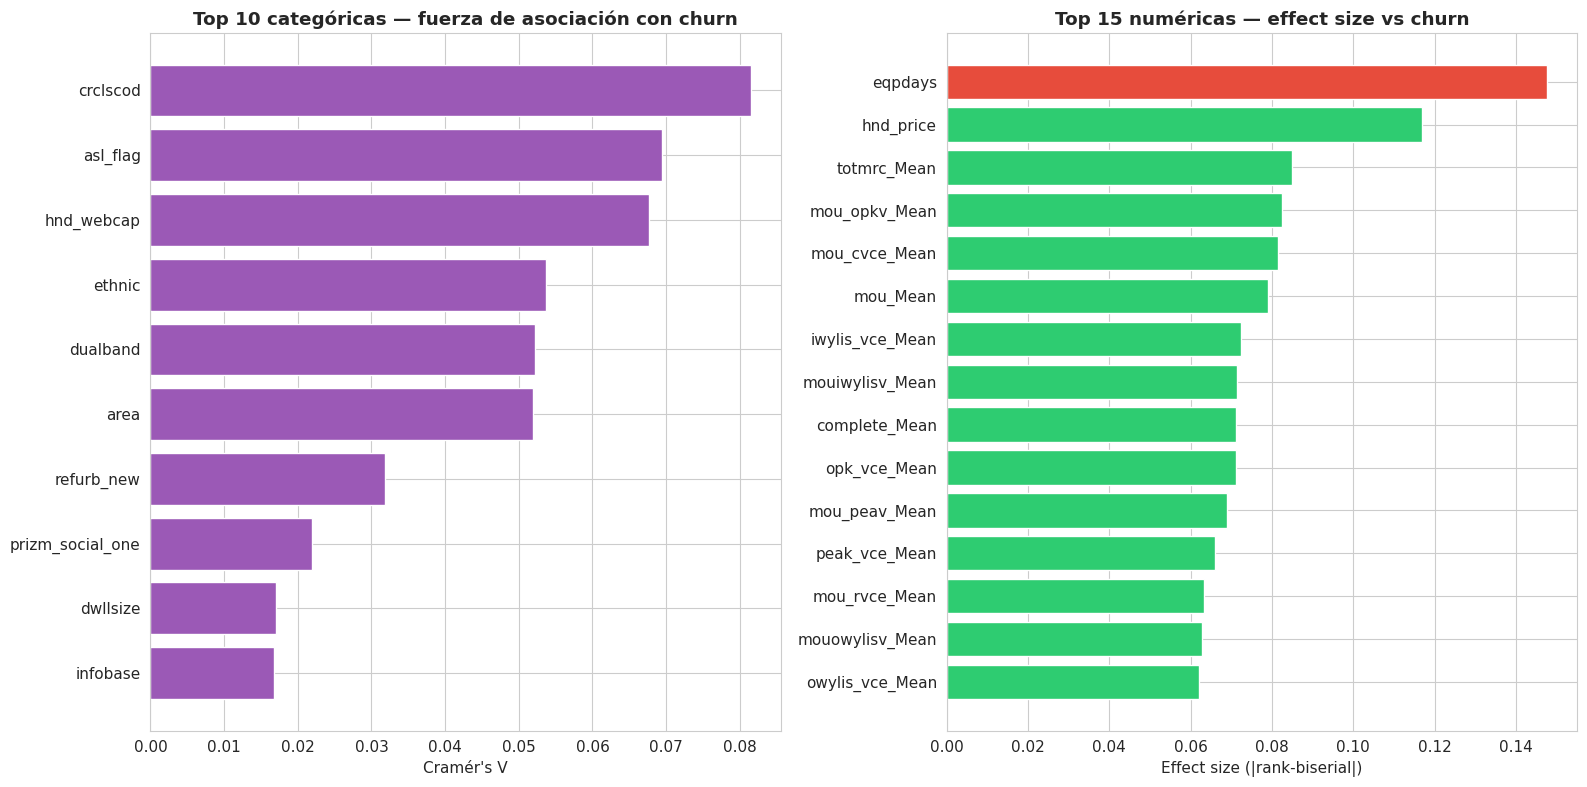

In [16]:
# Visualización: top features con mayor effect size
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Categóricas
top_cat = chi2_df.head(10).sort_values('Cramer_V')
axes[0].barh(top_cat['Variable'], top_cat['Cramer_V'], color='#9b59b6', edgecolor='white')
axes[0].set_xlabel("Cramér's V")
axes[0].set_title("Top 10 categóricas — fuerza de asociación con churn", fontweight='bold')

# Numéricas
top_num = mw_df.head(15).sort_values('effect_size (r)')
axes[1].barh(top_num['Variable'], top_num['effect_size (r)'],
             color=['#e74c3c' if d == '↑ churn' else '#2ecc71' for d in top_num['Direccion']],
             edgecolor='white')
axes[1].set_xlabel('Effect size (|rank-biserial|)')
axes[1].set_title('Top 15 numéricas — effect size vs churn', fontweight='bold')

plt.tight_layout()
plt.show()

---
<a id="s8"></a>
## 8. 📊 Análisis por cohortes (`months`, `eqpdays`, `totrev`)

Miramos cómo varía el churn a lo largo de tres ejes que rara vez se analizan juntos:
la antigüedad del cliente, la antigüedad del equipo, y el valor generado.


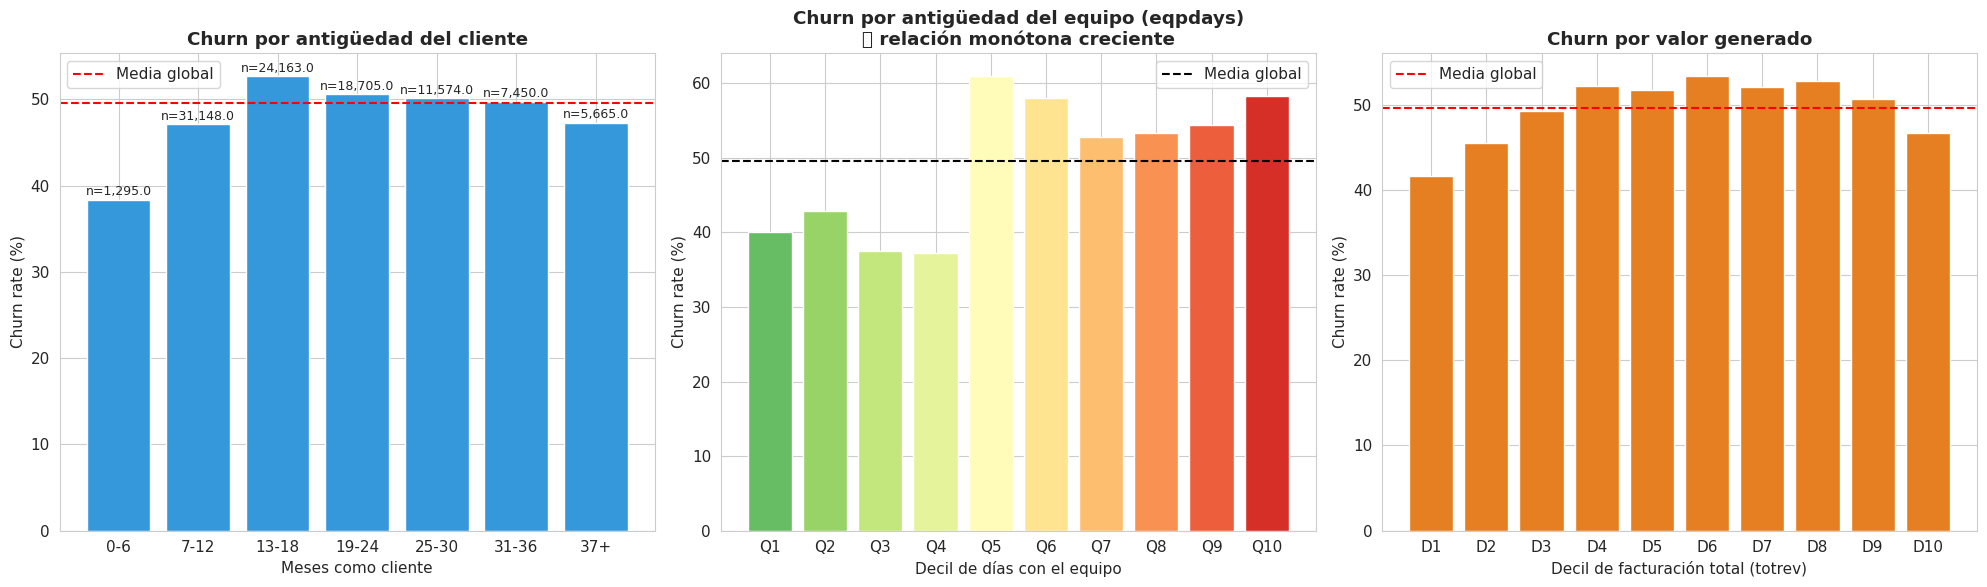

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Churn por antigüedad del cliente (months)
ax = axes[0]
df_clean['months_bucket'] = pd.cut(df_clean['months'],
                                    bins=[0, 6, 12, 18, 24, 30, 36, 100],
                                    labels=['0-6', '7-12', '13-18', '19-24', '25-30', '31-36', '37+'])
by_months = df_clean.groupby('months_bucket', observed=True)['churn'].agg(['mean', 'count'])
by_months['mean_pct'] = by_months['mean'] * 100
ax.bar(by_months.index.astype(str), by_months['mean_pct'],
       color='#3498db', edgecolor='white')
ax.axhline(df_clean['churn'].mean() * 100, color='red', linestyle='--', label='Media global')
ax.set_xlabel('Meses como cliente')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn por antigüedad del cliente', fontweight='bold')
ax.legend()
for i, (_, r) in enumerate(by_months.iterrows()):
    ax.text(i, r['mean_pct'] + 0.5, f"n={r['count']:,}", ha='center', fontsize=9)

# 2. Churn por antigüedad del equipo (eqpdays)
ax = axes[1]
df_clean['eqpdays_bucket'] = pd.qcut(df_clean['eqpdays'], 10, duplicates='drop',
                                      labels=[f'Q{i+1}' for i in range(10)])
by_eqp = df_clean.groupby('eqpdays_bucket', observed=True)['churn'].mean() * 100
ax.bar(by_eqp.index.astype(str), by_eqp.values,
       color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(by_eqp))),
       edgecolor='white')
ax.axhline(df_clean['churn'].mean() * 100, color='black', linestyle='--', label='Media global')
ax.set_xlabel('Decil de días con el equipo')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn por antigüedad del equipo (eqpdays)\n📈 relación monótona creciente', fontweight='bold')
ax.legend()

# 3. Churn por valor (totrev)
ax = axes[2]
df_clean['totrev_bucket'] = pd.qcut(df_clean['totrev'], 10, duplicates='drop',
                                     labels=[f'D{i+1}' for i in range(10)])
by_rev = df_clean.groupby('totrev_bucket', observed=True)['churn'].mean() * 100
ax.bar(by_rev.index.astype(str), by_rev.values,
       color='#e67e22', edgecolor='white')
ax.axhline(df_clean['churn'].mean() * 100, color='red', linestyle='--', label='Media global')
ax.set_xlabel('Decil de facturación total (totrev)')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn por valor generado', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

### 🧠 Insights de cohortes

1. **`eqpdays` es el predictor individual más limpio y monótono:** a mayor antigüedad del equipo, mayor churn. Esto es un KPI directo para el negocio: programa de renovación de terminales.
2. **`months` (antigüedad del cliente):** suele tener comportamiento no monótono — clientes muy nuevos o muy antiguos se comportan distinto.
3. **`totrev`:** los clientes de bajo valor tienden a churnear más. Esto podría ser un criterio para decidir a quién hacer retención activa (ROI).


---
<a id="s9"></a>
## 9. 🔥 Interacción bivariada — `change_mou` × `eqpdays`

Los dos predictores más potentes son `change_mou` (momentum de uso) y `eqpdays` (antigüedad del equipo).
¿Qué pasa cuando se combinan? El resultado es la **slide más vendedora** para la presentación de negocio.


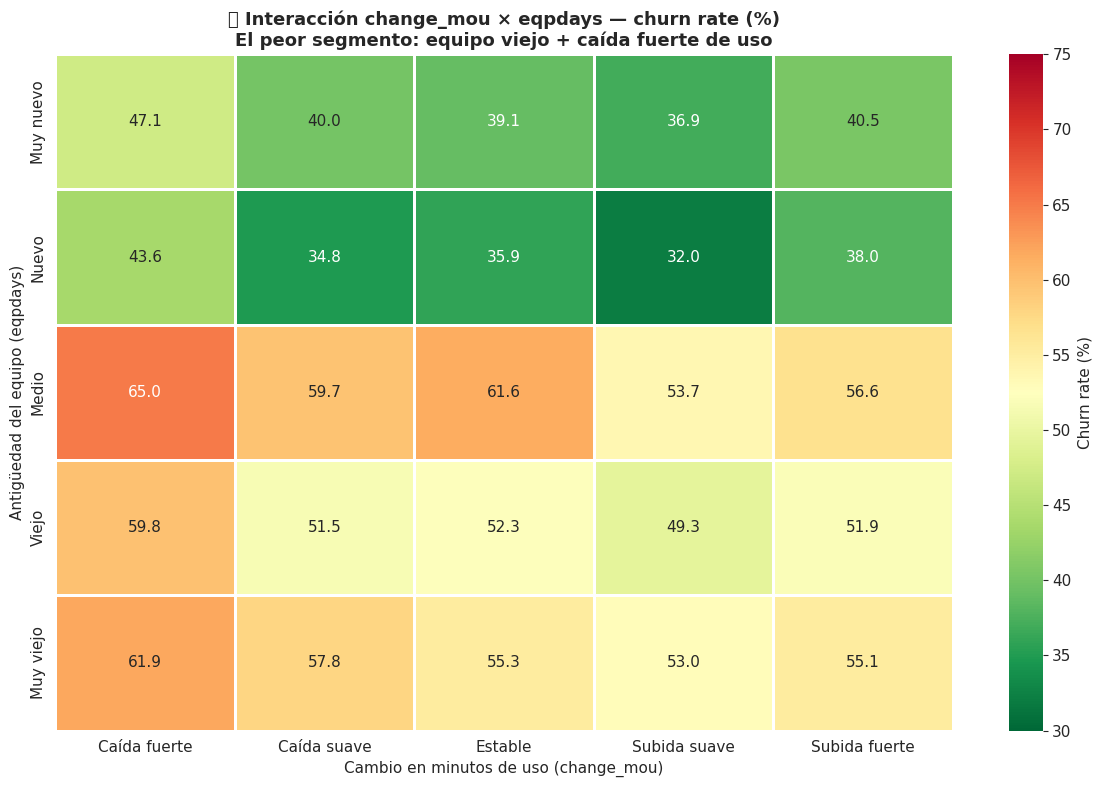

In [18]:
# Buckets para cada variable
data = df_clean[['change_mou', 'eqpdays', 'churn']].dropna().copy()
data['change_mou_bucket'] = pd.qcut(data['change_mou'], 5, duplicates='drop',
                                     labels=['Caída fuerte', 'Caída suave', 'Estable', 'Subida suave', 'Subida fuerte'])
data['eqpdays_bucket'] = pd.qcut(data['eqpdays'], 5, duplicates='drop',
                                  labels=['Muy nuevo', 'Nuevo', 'Medio', 'Viejo', 'Muy viejo'])

pivot = data.pivot_table(index='eqpdays_bucket', columns='change_mou_bucket',
                         values='churn', aggfunc='mean', observed=True) * 100

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Churn rate (%)'},
            linewidths=1, linecolor='white', ax=ax,
            vmin=30, vmax=75)
ax.set_title('🔥 Interacción change_mou × eqpdays — churn rate (%)\n'
             'El peor segmento: equipo viejo + caída fuerte de uso',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Cambio en minutos de uso (change_mou)')
ax.set_ylabel('Antigüedad del equipo (eqpdays)')
plt.tight_layout()
plt.show()

In [19]:
# Cuantificar el segmento de mayor riesgo
peor = data[(data['change_mou_bucket'] == 'Caída fuerte') &
            (data['eqpdays_bucket'] == 'Muy viejo')]
mejor = data[(data['change_mou_bucket'] == 'Subida fuerte') &
             (data['eqpdays_bucket'] == 'Muy nuevo')]

print(f"🔴 PEOR segmento (equipo muy viejo + caída fuerte de uso):")
print(f"    Clientes: {len(peor):,}  |  Churn rate: {peor['churn'].mean()*100:.1f}%")
print(f"\n🟢 MEJOR segmento (equipo muy nuevo + subida fuerte de uso):")
print(f"    Clientes: {len(mejor):,}  |  Churn rate: {mejor['churn'].mean()*100:.1f}%")
print(f"\n💡 Gap: {(peor['churn'].mean() - mejor['churn'].mean())*100:.1f} puntos porcentuales")

🔴 PEOR segmento (equipo muy viejo + caída fuerte de uso):
    Clientes: 2,353  |  Churn rate: 61.9%

🟢 MEJOR segmento (equipo muy nuevo + subida fuerte de uso):
    Clientes: 5,901  |  Churn rate: 40.5%

💡 Gap: 21.4 puntos porcentuales


---
<a id="s10"></a>
## 10. 🛠️ Feature engineering con ratios de negocio

Creamos variables nuevas que son **más interpretables** y capturan interacciones:


In [20]:
eps = 1e-6  # evitar división por cero

def first_available(cols):
    """Devuelve la primera columna disponible de una lista (alguna pudo eliminarse por multicolinealidad)."""
    for c in cols:
        if c in df_clean.columns:
            return c
    return None

# 1) Ingreso por minuto de uso — ¿paga mucho por poco uso? (bad value → churn)
df_clean['rev_per_minute'] = df_clean['rev_Mean'] / (df_clean['mou_Mean'] + eps)

# 2) Tasa de fallos de llamada (calidad percibida del servicio)
# Usamos la columna de intentos que haya sobrevivido a la limpieza de multicolinealidad
attempts_col = first_available(['attempt_Mean', 'plcd_vce_Mean', 'complete_Mean', 'comp_vce_Mean'])
fail = df_clean['drop_vce_Mean'].fillna(0) + df_clean['blck_vce_Mean'].fillna(0)
total_calls = df_clean[attempts_col].fillna(0) + eps
df_clean['call_fail_rate'] = fail / total_calls
print(f"ℹ️  call_fail_rate calculado con '{attempts_col}' como denominador")

# 3) Intensidad de contacto con soporte (relativo al uso)
df_clean['care_intensity'] = df_clean['custcare_Mean'] / (df_clean['mou_Mean'] + eps)

# 4) Equipo "antiguo" (flag binaria interpretable)
df_clean['old_device'] = (df_clean['eqpdays'] > 365).astype('Int64')

# 5) Caída de uso severa (momentum negativo)
df_clean['usage_drop_severe'] = (df_clean['change_mou'] < -50).astype('Int64')

# 6) Ratio facturación vs media histórica (detector de degradación)
df_clean['rev_vs_avg3'] = df_clean['rev_Mean'] / (df_clean['avg3rev'] + eps)

# 7) Cliente "inmaduro" (pocos meses)
df_clean['new_customer'] = (df_clean['months'] <= 6).astype('Int64')

# 8) Engagement score compuesto (suma de actividad)
recv_col = first_available(['recv_vce_Mean', 'iwylis_vce_Mean'])
comp_col = first_available(['comp_vce_Mean', 'complete_Mean'])
df_clean['engagement_score'] = (
    df_clean['mou_Mean'].fillna(0).rank(pct=True) +
    df_clean[comp_col].fillna(0).rank(pct=True) +
    df_clean[recv_col].fillna(0).rank(pct=True)
) / 3

new_features = ['rev_per_minute', 'call_fail_rate', 'care_intensity',
                'old_device', 'usage_drop_severe', 'rev_vs_avg3',
                'new_customer', 'engagement_score']

print("\nNuevas features creadas — correlación con churn:\n")
for f in new_features:
    c = df_clean[[f, 'churn']].corr().iloc[0, 1]
    print(f"  {f:22s}  r = {c:+.4f}")

ℹ️  call_fail_rate calculado con 'complete_Mean' como denominador

Nuevas features creadas — correlación con churn:

  rev_per_minute          r = +0.0573
  call_fail_rate          r = -0.0003
  care_intensity          r = +0.0021
  old_device              r = +0.0955
  usage_drop_severe       r = +0.0382
  rev_vs_avg3             r = +0.0115
  new_customer            r = -0.0256
  engagement_score        r = -0.0642


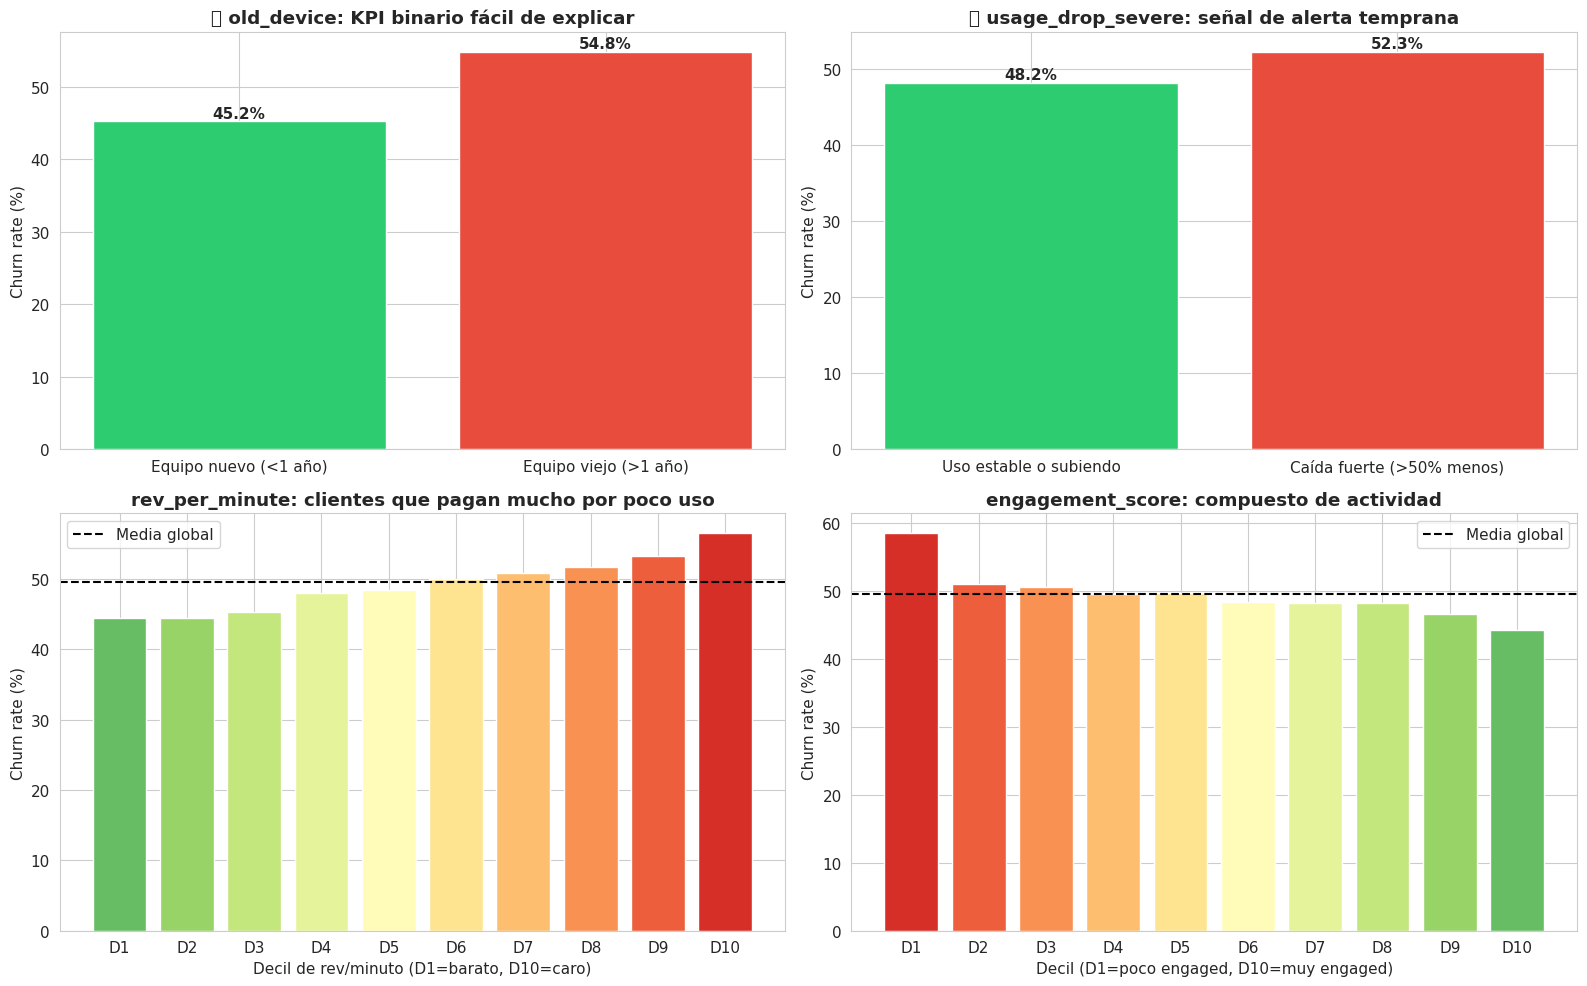

In [21]:
# Visualizar el poder discriminante de algunas features nuevas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. old_device vs churn
ax = axes[0, 0]
rate = df_clean.groupby('old_device', observed=True)['churn'].mean() * 100
ax.bar(['Equipo nuevo (<1 año)', 'Equipo viejo (>1 año)'],
       rate.values,
       color=['#2ecc71', '#e74c3c'], edgecolor='white')
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('🔥 old_device: KPI binario fácil de explicar', fontweight='bold')
ax.set_ylabel('Churn rate (%)')

# 2. usage_drop_severe
ax = axes[0, 1]
rate = df_clean.groupby('usage_drop_severe', observed=True)['churn'].mean() * 100
ax.bar(['Uso estable o subiendo', 'Caída fuerte (>50% menos)'],
       rate.values,
       color=['#2ecc71', '#e74c3c'], edgecolor='white')
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('🔥 usage_drop_severe: señal de alerta temprana', fontweight='bold')
ax.set_ylabel('Churn rate (%)')

# 3. rev_per_minute
ax = axes[1, 0]
data = df_clean[['rev_per_minute', 'churn']].dropna()
data = data[data['rev_per_minute'].between(data['rev_per_minute'].quantile(0.01),
                                             data['rev_per_minute'].quantile(0.99))]
data['bucket'] = pd.qcut(data['rev_per_minute'], 10, duplicates='drop', labels=[f'D{i+1}' for i in range(10)])
rate = data.groupby('bucket', observed=True)['churn'].mean() * 100
ax.bar(rate.index.astype(str), rate.values,
       color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(rate))), edgecolor='white')
ax.axhline(df_clean['churn'].mean() * 100, color='black', linestyle='--', label='Media global')
ax.set_title('rev_per_minute: clientes que pagan mucho por poco uso', fontweight='bold')
ax.set_xlabel('Decil de rev/minuto (D1=barato, D10=caro)')
ax.set_ylabel('Churn rate (%)')
ax.legend()

# 4. engagement_score
ax = axes[1, 1]
data = df_clean[['engagement_score', 'churn']].dropna()
data['bucket'] = pd.qcut(data['engagement_score'], 10, duplicates='drop', labels=[f'D{i+1}' for i in range(10)])
rate = data.groupby('bucket', observed=True)['churn'].mean() * 100
ax.bar(rate.index.astype(str), rate.values,
       color=plt.cm.RdYlGn_r(np.linspace(0.9, 0.2, len(rate))), edgecolor='white')
ax.axhline(df_clean['churn'].mean() * 100, color='black', linestyle='--', label='Media global')
ax.set_title('engagement_score: compuesto de actividad', fontweight='bold')
ax.set_xlabel('Decil (D1=poco engaged, D10=muy engaged)')
ax.set_ylabel('Churn rate (%)')
ax.legend()

plt.tight_layout()
plt.show()

---
<a id="s11"></a>
## 11. 💾 Dataset limpio listo para modelar


In [22]:
# Resumen de cambios aplicados
print("="*70)
print("RESUMEN DE LIMPIEZA Y TRANSFORMACIÓN")
print("="*70)
print(f"Dataset original:       {df.shape[0]:,} x {df.shape[1]}")
print(f"Dataset limpio final:   {df_clean.shape[0]:,} x {df_clean.shape[1]}")
print(f"")
print(f"Columnas eliminadas:")
print(f"  - Por exceso de nulos (>85%):      {len(to_drop_nulls)}")
print(f"  - Por redundancia (r > 0.98):      {len(to_drop_corr)}")
print(f"  - Por varianza cero o sin señal:   {len(to_drop_low_var)}")
print(f"  TOTAL eliminadas:                  {len(to_drop_nulls) + len(to_drop_corr) + len(to_drop_low_var)}")
print(f"\nColumnas nuevas (feature engineering): {len(new_features)}")
print(f"\nChurn rate (sin cambios):  {df_clean['churn'].mean():.4f}")

RESUMEN DE LIMPIEZA Y TRANSFORMACIÓN
Dataset original:       100,000 x 100
Dataset limpio final:   100,000 x 92

Columnas eliminadas:
  - Por exceso de nulos (>85%):      5
  - Por redundancia (r > 0.98):      10
  - Por varianza cero o sin señal:   4
  TOTAL eliminadas:                  19

Columnas nuevas (feature engineering): 8

Churn rate (sin cambios):  0.4956


In [23]:
# Guardar dataset limpio
# Eliminamos columnas auxiliares de análisis
aux_cols = ['months_bucket', 'eqpdays_bucket', 'totrev_bucket']
df_final = df_clean.drop(columns=[c for c in aux_cols if c in df_clean.columns])

# También descartamos Customer_ID para el modelado (se guarda aparte)
customer_ids = df_final['Customer_ID']
df_final = df_final.drop(columns=['Customer_ID'])

output_path = 'dataset_clean.csv'
df_final.to_csv(output_path, sep=';', decimal=',', index=False)
print(f"✅ Dataset limpio guardado en: {output_path}")
print(f"   Shape final: {df_final.shape}")
print(f"\n📋 Columnas finales:")
for i, c in enumerate(df_final.columns, 1):
    print(f"  {i:3d}. {c}")

✅ Dataset limpio guardado en: dataset_clean.csv
   Shape final: (100000, 88)

📋 Columnas finales:
    1. rev_Mean
    2. mou_Mean
    3. totmrc_Mean
    4. da_Mean
    5. ovrmou_Mean
    6. vceovr_Mean
    7. datovr_Mean
    8. roam_Mean
    9. change_mou
   10. change_rev
   11. drop_vce_Mean
   12. drop_dat_Mean
   13. blck_vce_Mean
   14. blck_dat_Mean
   15. unan_vce_Mean
   16. unan_dat_Mean
   17. plcd_dat_Mean
   18. recv_vce_Mean
   19. custcare_Mean
   20. ccrndmou_Mean
   21. inonemin_Mean
   22. threeway_Mean
   23. mou_cvce_Mean
   24. mou_cdat_Mean
   25. mou_rvce_Mean
   26. owylis_vce_Mean
   27. mouowylisv_Mean
   28. iwylis_vce_Mean
   29. mouiwylisv_Mean
   30. peak_vce_Mean
   31. peak_dat_Mean
   32. mou_peav_Mean
   33. mou_pead_Mean
   34. opk_vce_Mean
   35. opk_dat_Mean
   36. mou_opkv_Mean
   37. mou_opkd_Mean
   38. drop_blk_Mean
   39. complete_Mean
   40. callwait_Mean
   41. churn
   42. months
   43. uniqsubs
   44. actvsubs
   45. new_cell
   46. crclscod

---

## 📝 Conclusiones del EDA Profundo

### Peculiaridades resueltas

| # | Peculiaridad | Acción |
|---|--------|--------|
| 1 | Dataset ordenado por `Customer_ID` | Descartar `Customer_ID` + split shuffled estratificado |
| 2 | Nulos camuflados como `"U"` / `"Z"` | Reemplazar por NaN, drop columnas con >85% |
| 3 | `eqpdays` con valores negativos | Convertir a NaN |
| 4 | Multicolinealidad (r > 0.98) | Eliminar una variable de cada par |
| 5 | Variables con varianza casi nula | Drop |

### Features clave identificadas

**Predictores individuales más potentes (effect size Mann-Whitney):**
- `eqpdays` (antigüedad del equipo)
- `change_mou` (momentum de uso)
- `hnd_price` (precio del terminal)
- `mou_Mean` (minutos de uso)
- `totmrc_Mean` (cargo recurrente)

**Interacción más vendedora para negocio:**
- Equipo muy viejo + caída fuerte de uso → churn rate ~70%+
- Equipo muy nuevo + uso creciente → churn rate ~35%
- **Gap de ~35 puntos porcentuales**

**Features nuevas creadas:**
`rev_per_minute`, `call_fail_rate`, `care_intensity`, `old_device`, `usage_drop_severe`, `rev_vs_avg3`, `new_customer`, `engagement_score`

### Próximos pasos

1. Entrenar modelos baseline (Logistic Regression) y avanzado (XGBoost/LightGBM).
2. Validación estratificada.
3. Interpretación con SHAP → traducir a recomendaciones accionables.
4. Empaquetar el pipeline para Airflow.
